# Latent Regime Momentum
## Student-t hidden-state inference for dynamic equity–gold–cash allocation

**Research question:** Can a latent volatility regime improve the risk profile of a cross-sectional momentum portfolio enough to justify the return sacrificed by defensive allocation?

This notebook contains the submitted implementation and its saved execution outputs. The publication pass did **not** rerun the full historical model. Input paths have been made portable; mathematical and trading rules are retained. See the repository README for comparison experiments, and `results/published/provenance.json` for source identity.

**Read the results as historical research, not an untouched out-of-sample result.** The stock universe consists of current S&P 500 constituents; the 2017–2026 interval was repeatedly observed during development. The model estimates volatility states, not the probability of a market crash.

The research chain is: data contract → momentum ranking → latent-state estimation → allocation → execution accounting → benchmarks → results → limitations.

$$w_{\mathrm{equity},t}=(1-p_t)^\gamma,\quad
w_{\mathrm{cash},t}=w_{\mathrm{gold},t}=\frac{1-(1-p_t)^\gamma}{2},\quad\gamma=1.$$

The code retains the legacy `train`, `val`, and `test` keys for reproducibility. In the report, 2010–2016 is the development interval, shown as two subperiods; 2017–2026-09-30 is the historical test/diagnostic interval. No automated validation-set hyperparameter search is implemented.


## 1. Environment and controls

NumPy and pandas implement the model and portfolio accounting; Matplotlib creates the figures. The 12-ETF list is an auxiliary benchmark, not the stock selection universe. `COST = 0.0007` charges 7 basis points of each security purchase or sale; cash is exempt. The submitted global warning suppression is retained, so a quiet log does not prove numerical robustness.

Place licensed input files in `data/`, or set `LRM_DATA_DIR`. Paths no longer identify the author's local machine. The notebook does not download market data.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, json, warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

ETF_UNIVERSE = ["SPY","EFA","EEM","TLT","IEF","HYG","GLD","USO","DBA","VNQ","FXE","UUP"]
COST = 0.0007  # 7bps/边
print("imports sucessfully")

from pathlib import Path
import os

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src" / "lrm").is_dir()), Path.cwd()
)
DATA_DIR = Path(os.environ.get("LRM_DATA_DIR", str(PROJECT_ROOT / "data")))
OUTPUT_DIR = PROJECT_ROOT / "results" / "local"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


imports sucessfully


## 2. Data contract: prices, marks, and tradeability

Read `etf_prices.csv` and `sp500_prices.csv` with dates in the first column and one asset per column. Remove all-empty stock rows and align ETFs to the stock calendar. Reject duplicate dates/assets, nonascending dates and nonpositive prices. SPY and GLD must be present on every stock-calendar date.

Cash is represented by a constant price of 1 and a zero daily return. Stock valuation may carry the last quote for one trading day, but tradeability uses the **original quote**. A stale valuation is not permission to trade at a stale price. Held assets with unusable returns and attempted trades without quotes are rejected by the execution engine.

These checks do not establish point-in-time membership, dividend adjustment or correct delisting treatment. The original vendor and adjustment provenance have not been independently established. See `data/README.md` before reproducing.


In [7]:
# ETF 数据（12 只 + VIX，2008-01 起）
px_etf = pd.read_csv(DATA_DIR / "etf_prices.csv", index_col=0, parse_dates=True)
# S&P500 现成分股（约 500 只，2008-01 起）
px_spx = pd.read_csv(DATA_DIR / "sp500_prices.csv", index_col=0, parse_dates=True)

print("ETF:", px_etf.shape, px_etf.index[0].date(), "->", px_etf.index[-1].date())
print("SPX:", px_spx.shape, px_spx.index[0].date(), "->", px_spx.index[-1].date())

# 删除节假日等无行情的整行 NaN：空行产生的 NaN 收益进入 Hamilton 扩展窗口后
# 会让之后的 P 被永久冻结（曾导致 2026-05 后 P 冻结 19 周）
# 以股票实际交易日期作为统一日历
px_spx = px_spx.loc[px_spx.notna().any(axis=1)].copy()

for name, frame in [("ETF", px_etf), ("stocks", px_spx)]:
    if frame.index.has_duplicates or frame.columns.has_duplicates:
        raise ValueError(f"{name}: 日期或资产列重复")
    if not frame.index.is_monotonic_increasing:
        raise ValueError(f"{name}: 日期必须升序")
    if (frame <= 0).any().any():
        raise ValueError(f"{name}: 存在非正价格")

px_etf = px_etf.reindex(px_spx.index).copy()

if px_etf[["SPY", "GLD"]].isna().any().any():
    raise ValueError("股票交易日上的 SPY/GLD 报价缺失，请先检查数据")

px_etf["CASH"] = 1.0

# 原始报价用于检查是否可以成交。
# 最多沿用一个交易日旧价格，仅用于估值，不修改原始报价。
marks_spx = px_spx.ffill(limit=1)

rets_spx = marks_spx.pct_change(fill_method=None)
rets_etf = px_etf.pct_change(fill_method=None)
rets_etf["CASH"] = 0.0

rets_all = pd.concat( [rets_spx, rets_etf[["CASH", "GLD"]]], axis=1, join="inner", )

tradable = pd.concat(
    [px_spx.notna(), px_etf[["CASH", "GLD"]].notna()],
    axis=1,
    join="inner",
).reindex_like(rets_all)


ETF: (4719, 13) 2008-01-02 -> 2026-10-01
SPX: (4716, 503) 2008-01-02 -> 2026-09-30


## 3. Calendar and evaluation intervals

`month_ends` selects the last observed trading date in each calendar month. A truncated final month is treated as an endpoint, which must be considered when appending partial data. `splits` defines 2010–2012, 2013–2016 and 2017–2026-09-30 reporting slices; 2008–2009 appears only in the full-history warm-up view.

These slices do not control model fitting. The HMM is refit weekly on expanding data available at each date. The account is simulated continuously, then sliced for statistics; each period inherits the previous holdings rather than restarting from cash. There is no parameter grid search in `val`.


In [10]:
def month_ends(idx):
    idx = pd.DatetimeIndex(idx)
    per = idx.to_period("M")
    out = []
    for p in per.unique():
        out.append(idx[per == p][-1])
    return pd.DatetimeIndex(sorted(out))

def splits(idx):
    return {
        "train": (idx >= "2010-01-01") & (idx < "2013-01-01"),
        "val":   (idx >= "2013-01-01") & (idx < "2017-01-01"),
        "test":  (idx >= "2017-01-01") & (idx < "2026-10-01"),
    }

print("month_ends 样例:", month_ends(px_etf.index)[:3].date)


month_ends 样例: [datetime.date(2008, 1, 31) datetime.date(2008, 2, 29)
 datetime.date(2008, 3, 31)]


## 4. Two-state Student-t HMM

The observation is the SPY log return in percentage-point units. Each latent state has a different location and scale, with a shared estimated degrees-of-freedom parameter:

$$y_t=100\log(P_t^{SPY}/P_{t-1}^{SPY}),\qquad y_t\mid s_t=j\sim t_\nu(\mu_j,\sigma_j).$$

`sig2` stores **scale squared**, not Student-t variance. Because $\nu>2$, the conditional variance is $\sigma_j^2\nu/(\nu-2)$. Shared $\nu$ makes sorting by scale equivalent to sorting by variance. The larger-scale state is labeled high volatility.

### Inference and estimation

`_filter_smooth` performs forward filtering and backward smoothing. The initial distribution `pi` is used directly for the first observation; subsequent observations use the transition matrix. Filtering produces endpoint probabilities for decisions. Smoothing uses later observations within the fitting window and is used only for estimation.

$$\alpha_{t|t-1}=P^\top\alpha_{t-1|t-1},\qquad
\alpha_{t|t,j}=\frac{f_j(y_t)\alpha_{t|t-1,j}}{\sum_k f_k(y_t)\alpha_{t|t-1,k}}.$$

`_em_run` estimates locations, scales, transition probabilities, the initial state distribution and shared degrees of freedom. Student-t latent precision weights reduce the influence of extreme residuals on location estimation. Degrees of freedom are constrained to `[2.05, 300]`; scale and transition floors are numerical safeguards.

The stopping criterion is evaluated before the next parameter update. A material likelihood decrease is not successful convergence. The final parameters are filtered again, and state permutations are applied consistently to parameters and probabilities.

`hamilton_em` first tries a warm start with a 300-iteration budget, followed by a cold restart with at least 1,000 iterations if needed. The retained `seed` argument does not randomize the deterministic initialization. Density calculations remain in probability space with a small floor, not a fully log-domain implementation.

Student-t is a distributional choice; it does not introduce an explicit crash state or guarantee smoother probabilities. Historical interior filtering probabilities from a later fit must never be rewritten into earlier trading decisions.


In [13]:
def _norm_pdf(y, mu, sig):
    return np.exp(-0.5 * ((y - mu) / sig) ** 2) / (np.sqrt(2 * np.pi) * sig)

import math

def _digamma(x):
    r = 0.0
    while x < 8.0:
        r -= 1.0 / x; x += 1.0
    inv = 1.0 / x; inv2 = inv * inv
    return r + math.log(x) - 0.5 * inv - inv2 * (1/12 - inv2 * (1/120 - inv2 / 252))

def _t_pdf(y2, mu, sig, nu):
    z = (y2 - mu) / sig
    logc = math.lgamma((nu + 1) / 2) - math.lgamma(nu / 2) - 0.5 * math.log(nu * math.pi)
    return np.exp(logc - np.log(sig) - (nu + 1) / 2 * np.log1p(z ** 2 / nu))


def _filter_smooth(y, mu, sig2, P, nu, dist, var_floor, xi0):
    """给定参数跑一遍 Hamilton 过滤 + Kim 平滑。返回 (filt, smooth, pred, ll, ok)。"""
    T = len(y)
    sig = np.sqrt(np.maximum(sig2, var_floor))
    if dist == "t":
        eta = _t_pdf(y[:, None], mu[None, :], sig[None, :], nu) + 1e-300
    else:
        eta = _norm_pdf(y[:, None], mu[None, :], sig[None, :]) + 1e-300
    filt = np.zeros((T, 2)); pred = np.zeros((T, 2)); xi = xi0.copy(); ll = 0.0
    for t in range(T):
        # xi0 表示第一期观测对应状态的先验。
        # 第一笔观测直接使用 xi0，之后才进行状态转移。
        pr = xi0.copy() if t == 0 else P.T @ xi
        pred[t] = pr
        num = pr * eta[t]; den = num.sum()
        if den <= 0 or not np.isfinite(den):
            return filt, filt, pred, -np.inf, False
        xi = num / den; filt[t] = xi; ll += np.log(den)
    smooth = np.zeros((T, 2)); smooth[-1] = filt[-1]
    for t in range(T - 2, -1, -1):
        ratio = smooth[t + 1] / np.maximum(pred[t + 1], 1e-300)
        smooth[t] = filt[t] * ((P * ratio[None, :]).sum(axis=1))
        smooth[t] /= smooth[t].sum()
    return filt, smooth, pred, ll, True

def _em_run(y, n_iter, init, var_floor, seed, dist, nu_init):
    """单次 EM。filt/smooth/loglik 用最终参数重过滤得到，与返回参数严格一致。"""
    y = np.asarray(y, dtype=float); T = len(y)
    if init is None:
        order = np.argsort(np.abs(y))
        mu = np.array([y[order[:T//2]].mean(), y[order[T//2:]].mean()])
        sig2 = np.array([y[order[:T//2]].var(), y[order[T//2:]].var()]) + var_floor
        P = np.array([[0.95, 0.05], [0.10, 0.90]]); nu = float(nu_init)
    else:
        mu = init["mu"].copy(); sig2 = init["sig2"].copy(); P = init["P"].copy()
        nu = float(init.get("nu", nu_init))
    nu = min(max(nu, 2.05), 300.0)
    xi0 = np.array(init.get("pi", [0.5, 0.5]) if init is not None else [0.5, 0.5], dtype=float, copy=True,)

    if not np.isfinite(xi0).all() or (xi0 < 0).any() or xi0.sum() <= 0:
        raise ValueError("无效初始状态概率 pi")

    xi0 /= xi0.sum()
    ll_old, converged = -np.inf, False

    filt = smooth = pred = None
    for _ in range(n_iter):
        filt, smooth, pred, ll, ok = _filter_smooth(y, mu, sig2, P, nu, dist, var_floor, xi0)
        if not ok:
            return dict(mu=mu, sig2=sig2, P=P, nu=nu, filt=filt, smooth=filt, loglik=-np.inf, converged=False)
        # 判断当前参数对应的似然是否收敛。
        # 必须放在下一次 M 步更新之前。
        if np.isfinite(ll_old):
            change = ll - ll_old

            if change < -1e-8 * (abs(ll_old) + 1):
                # 出现明显似然下降，不能视作成功收敛。
                break

            if abs(change) < 1e-7 * (abs(ll_old) + 1):
                converged = True
                break
                
        N = smooth.sum(axis=0) + 1e-300
        if dist == "t":
            d = (y[:, None] - mu[None, :]) ** 2 / np.maximum(sig2[None, :], var_floor)
            w = (nu + 1) / (nu + d)
            elog = _digamma((nu + 1) / 2) - np.log((nu + d) / 2)
            sw = smooth * w
            mu = (sw * y[:, None]).sum(axis=0) / (sw.sum(axis=0) + 1e-300)
            sig2 = np.maximum((sw * (y[:, None] - mu[None, :]) ** 2).sum(axis=0) / N, var_floor)
            C = float((smooth * (elog - w)).sum()) / T
            def f(v):
                return math.log(v / 2) - _digamma(v / 2) + 1.0 + C
            lo, hi = 2.05, 300.0
            if f(lo) <= 0: nu = lo
            elif f(hi) >= 0: nu = hi
            else:
                for _ in range(60):
                    mid = 0.5 * (lo + hi)
                    if f(mid) > 0: lo = mid
                    else: hi = mid
                nu = 0.5 * (lo + hi)
        else:
            mu = (smooth * y[:, None]).sum(axis=0) / N
            sig2 = np.maximum((smooth * (y[:, None] - mu[None, :]) ** 2).sum(axis=0) / N, var_floor)
        num_j = (filt[:-1, :, None] * P[None, :, :] * (smooth[1:] / np.maximum(pred[1:], 1e-300))[:, None, :])
        P = num_j.sum(axis=0) / np.maximum(num_j.sum(axis=(0, 2))[:, None], 1e-300)
        P = np.clip(P, 1e-6, 1 - 1e-6); P /= P.sum(axis=1, keepdims=True)
        xi0 = smooth[0] / smooth[0].sum()

        ll_old = ll
    # 用最终参数重跑一遍过滤/平滑，保证返回概率与返回参数一致
    filt, smooth, pred, ll, ok = _filter_smooth(y, mu, sig2, P, nu, dist, var_floor, xi0)
    if not ok:
        return dict(mu=mu, sig2=sig2, P=P, nu=nu, filt=filt, smooth=filt, loglik=-np.inf, converged=False)
    idx = np.argsort(sig2)

    mu = mu[idx]
    sig2 = sig2[idx]
    P = P[np.ix_(idx, idx)]
    xi0 = xi0[idx]

    filt = filt[:, idx]
    smooth = smooth[:, idx]

    return dict(
        mu=mu,
        sig2=sig2,
        P=P,
        pi=xi0.copy(),
        nu=(nu if dist == "t" else float("inf")),
        filt=filt,
        smooth=smooth,
        loglik=float(ll),
        converged=bool(converged),)

def hamilton_em( y, n_iter=300, init=None, var_floor=1e-8, seed=0, dist="t", nu_init=8.0, ):
    if dist not in ("gauss", "t"):
        raise ValueError("dist 只能是 'gauss' 或 't'")

    y = np.asarray(y, dtype=float)

    if y.ndim != 1 or len(y) < 4 or not np.isfinite(y).all():
        raise ValueError("HMM输入必须是连续、有限的一维收益序列")

    if n_iter < 1:
        raise ValueError("n_iter 必须大于0")

    # 不使用 cand is init 判断预算。
    # 初次拟合也是完整预算；失败后允许一次更充分的冷重启。
    attempts = [ (init, n_iter), (None, max(n_iter, 1000)), ]

    best = None
    errors = []

    for candidate, budget in attempts:
        try:
            out = _em_run( y, budget, candidate, var_floor, seed, dist, nu_init )
        except (ValueError, FloatingPointError, np.linalg.LinAlgError) as exc:
            errors.append(str(exc))
            continue

        if np.isfinite(out["loglik"]):
            if best is None or out["loglik"] > best["loglik"]:
                best = out

            if out["converged"]:
                return out

    if best is not None:
        best["converged"] = False
        return best

    # 上层必须明确处理失败，不能把它当成有效模型。
    return dict( converged=False, loglik=-np.inf, error="; ".join(errors) or "全部拟合候选失败", )


def turb_prob(filt, sig2):
    """高波动状态的滤波概率。"""
    return filt[:, int(np.argmax(sig2))]

print("hamilton ok")


hamilton ok


## 5. Synthetic implementation checks

A known 3,000-observation latent-state process is simulated for Gaussian and Student-t observations. Checks require convergence, consistent refiltered probabilities and likelihood, probabilities summing to one, and state classification accuracy above 75%. The Student-t simulation uses scale, not standard deviation.

Saved source outputs show Gaussian accuracy 0.924 and Student-t accuracy 0.907, with estimated Student-t degrees of freedom 8.377. These are implementation checks on simulated data, **not** market crash-avoidance win rates. The production signal below uses Student-t only.


In [16]:
rng = np.random.default_rng(7)

T = 3000
mu_t = np.array([0.05, -0.10])
sd_t = np.array([0.8, 2.5])
Pt = np.array([[0.97, 0.03], [0.08, 0.92]])

s = np.zeros(T, dtype=int)

for t in range(1, T):
    s[t] = int(rng.random() >= Pt[s[t - 1], 0])

for dist in ["gauss", "t"]:
    if dist == "gauss":
        shock = rng.normal(size=T)
    else:
        # 这里sd_t表示Student-t尺度，不是标准差。
        shock = rng.standard_t(df=8.0, size=T)

    y = mu_t[s] + sd_t[s] * shock

    out = hamilton_em( y, n_iter=300, seed=0, dist=dist, )

    assert out["converged"], f"{dist}: EM未收敛"

    rebuilt, _, _, rebuilt_ll, ok = _filter_smooth(
        y,
        out["mu"],
        out["sig2"],
        out["P"],
        out["nu"],
        dist,
        1e-8,
        out["pi"],
    )

    assert ok, f"{dist}: 最终参数过滤失败"
    assert np.allclose( rebuilt, out["filt"], rtol=0, atol=1e-10 ), f"{dist}: 返回概率与最终参数不一致"

    assert np.isclose( rebuilt_ll, out["loglik"] ), f"{dist}: 返回似然与最终参数不一致"

    assert np.allclose(rebuilt.sum(axis=1), 1.0)

    p = turb_prob(rebuilt, out["sig2"])
    acc = float(((p > 0.5).astype(int) == s).mean())

    assert acc > 0.75, f"{dist}: 合成状态恢复较差，accuracy={acc:.3f}"

    print( f"{dist}: converged=True | " f"accuracy={acc:.3f} | nu={out['nu']:.3f}" )

print("全部合成检查通过")
print("合成状态识别率不等于真实市场回撤保护成功率。")


gauss: converged=True | accuracy=0.924 | nu=inf
t: converged=True | accuracy=0.907 | nu=8.377
全部合成检查通过
合成状态识别率不等于真实市场回撤保护成功率。


## 6. From state probabilities to monthly positions

At each observed week-end, fit the HMM to all SPY returns then available, after at least 252 observations. On fitting failure, retain the last valid parameters and refilter the expanded observations: the probability keeps incorporating new data. Initial failure without a valid model stops execution. `regime_log` records convergence, fallbacks, consecutive failures, degrees of freedom and likelihoods.

Monthly decisions use the most recent weekly endpoint available by the month-end. This may be several trading days old. No later weekly estimate is backfilled into an earlier signal.

The stock score is exactly:

$$M_{i,t}=\frac{P_{i,t-21}}{P_{i,t-273}}-1.$$

This is a 252-trading-day return shifted by 21 days, not $P_{t-21}/P_{t-252}-1$. Rank finite scores with a current quote and select the top 100. There is no positive-momentum filter. Fewer than 100 eligible names means no new order: initially cash is held; subsequently existing positions remain.

The stock sleeve is equal weighted, then scaled by $(1-p)^\gamma$. Residual capital is split equally between cash and GLD. `GAMMA=1`; the retained `BAND` constant is unused. HMM controls total exposure, not individual stock ranking.


In [18]:
def week_ends(idx):
    idx = pd.DatetimeIndex(idx)
    per = idx.to_period("W")
    return pd.DatetimeIndex(sorted(idx[per == p][-1] for p in per.unique()))

def hamilton_pstress_weekly( px_etf, dist="t", n_iter=300, return_log=False, ):
    returns = np.log(px_etf["SPY"]).diff().iloc[1:] * 100

    if not np.isfinite(returns.to_numpy()).all():
        raise ValueError("SPY收益含NaN或无穷值，请先检查行情")

    p_w = pd.Series(np.nan, index=px_etf.index)
    last_good = None
    log_rows = []

    n_fail = 0
    consecutive_failures = 0

    for dt in week_ends(px_etf.index):
        y = returns.loc[:dt].to_numpy()

        if len(y) < 252:
            continue

        out = hamilton_em( y, n_iter=n_iter, init=last_good, dist=dist, )

        good = bool( out["converged"] and np.isfinite(out["loglik"]) )

        if good:
            last_good = { k: np.array(out[k], copy=True) for k in ["mu", "sig2", "P", "pi"] }
            last_good["nu"] = float(out["nu"])
            consecutive_failures = 0
        else:
            n_fail += 1
            consecutive_failures += 1

            if last_good is None:
                raise RuntimeError( f"{dt}: 初始模型未收敛，没有有效历史参数，停止回测" )

        # 成功或失败，都用实际采用的参数过滤截至当前的全部观测。
        # 失败时参数不更新，但新观测必须进入过滤。
        filt, _, _, used_ll, ok = _filter_smooth(
            y,
            last_good["mu"],
            last_good["sig2"],
            last_good["P"],
            last_good["nu"],
            dist,
            1e-8,
            last_good["pi"],
        )

        if not ok:
            raise RuntimeError(f"{dt}: 使用有效参数重新过滤也失败")

        p = float(turb_prob(filt, last_good["sig2"])[-1])
        p_w.loc[dt] = p

        log_rows.append(
            dict(
                date=dt,
                p=p,
                converged=good,
                fallback=not good,
                consecutive_failures=consecutive_failures,
                nu=last_good["nu"],
                attempted_loglik=float(out["loglik"]),
                used_loglik=float(used_ll),
            )
        )

        if len(log_rows) % 25 == 0:
            print( dist, "已完成周数:", len(log_rows), "截至:", dt.date(), "fallback:", n_fail, flush=True, )

    if not log_rows:
        raise ValueError("历史不足，无法生成HMM概率")

    log = pd.DataFrame(log_rows).set_index("date")

    print(f"Hamilton({dist}) fallback {n_fail} 次")

    if return_log:
        return p_w, log

    return p_w


GAMMA = 1.0   # 线性混合：股票仓位 = (1-P)^gamma
BAND = 0.10   # 月频版未使用（周频版的 no-trade band 参数，保留备查）

def r4c2_signal_monthly(px_spx, px_etf, gamma=GAMMA):
    me = month_ends(px_spx.index)

    # 保留原动量定义，但禁止隐式前向填充。
    mom = px_spx.pct_change(252, fill_method=None).shift(21)

    sleeve = pd.DataFrame( 0.0, index=me, columns=px_spx.columns, )

    for dt in me:
        score = ( mom.loc[dt] .replace([np.inf, -np.inf], np.nan) .dropna() )

        # 信号日必须存在原始报价。
        score = score[px_spx.loc[dt, score.index].notna()]

        if len(score) >= 100:
            sleeve.loc[dt, score.nlargest(100).index] = 1 / 100

    p_w, regime_log = hamilton_pstress_weekly( px_etf, dist="t", return_log=True, )
    p_w = p_w.dropna()

    p_m = ( p_w.reindex(p_w.index.union(me)) .sort_index() .ffill() .reindex(me) .dropna() )

    # 只有选股完整的月份才发出信号。
    # 暖启动期间保持现金，避免不完整权重或提前配置黄金。
    valid_dates = p_m.index[ np.isclose( sleeve.loc[p_m.index].sum(axis=1).to_numpy(), 1.0, ) ]
    p_m = p_m.loc[valid_dates]

    sig = pd.DataFrame( 0.0, index=valid_dates, columns=list(px_spx.columns) + ["CASH", "GLD"], )

    for dt in valid_dates:
        target_eq = float((1 - p_m.loc[dt]) ** gamma)

        sig.loc[dt, px_spx.columns] = sleeve.loc[dt] * target_eq
        sig.loc[dt, "CASH"] = (1 - target_eq) / 2
        sig.loc[dt, "GLD"] = (1 - target_eq) / 2

    assert np.isfinite(sig.to_numpy()).all()
    assert (sig.to_numpy() >= 0).all()
    assert np.allclose(sig.sum(axis=1), 1.0)

    return sig, p_m, regime_log


sig, p_stress, regime_log = r4c2_signal_monthly(px_spx, px_etf)
print("signal shape:", sig.shape)


t 已完成周数: 25 截至: 2009-06-19 fallback: 0
t 已完成周数: 50 截至: 2009-12-11 fallback: 0
t 已完成周数: 75 截至: 2010-06-04 fallback: 0
t 已完成周数: 100 截至: 2010-11-26 fallback: 0
t 已完成周数: 125 截至: 2011-05-20 fallback: 0
t 已完成周数: 150 截至: 2011-11-11 fallback: 0
t 已完成周数: 175 截至: 2012-05-04 fallback: 0
t 已完成周数: 200 截至: 2012-10-26 fallback: 0
t 已完成周数: 225 截至: 2013-04-19 fallback: 0
t 已完成周数: 250 截至: 2013-10-11 fallback: 0
t 已完成周数: 275 截至: 2014-04-04 fallback: 0
t 已完成周数: 300 截至: 2014-09-26 fallback: 0
t 已完成周数: 325 截至: 2015-03-20 fallback: 0
t 已完成周数: 350 截至: 2015-09-11 fallback: 0
t 已完成周数: 375 截至: 2016-03-04 fallback: 0
t 已完成周数: 400 截至: 2016-08-26 fallback: 0
t 已完成周数: 425 截至: 2017-02-17 fallback: 0
t 已完成周数: 450 截至: 2017-08-11 fallback: 0
t 已完成周数: 475 截至: 2018-02-02 fallback: 0
t 已完成周数: 500 截至: 2018-07-27 fallback: 0
t 已完成周数: 525 截至: 2019-01-18 fallback: 0
t 已完成周数: 550 截至: 2019-07-12 fallback: 0
t 已完成周数: 575 截至: 2020-01-03 fallback: 0
t 已完成周数: 600 截至: 2020-06-26 fallback: 0
t 已完成周数: 625 截至: 2020-12-18 fallback: 0
t 已

## 7. Execution: make the timing and accounting explicit

The account starts in cash. A signal computed at close $t$ is executed at close $t+1$. Old holdings earn the $t+1$ return; new holdings first earn the close-to-close return ending at $t+2$. Between trades, weights drift with prices.

The engine rejects malformed signals, negative weights, incomplete allocations, unavailable held-asset returns and untradeable orders. Output `weights` are beginning-of-day weights, not post-trade closing allocations.

### Self-financing costs

Let $d$ be pretrade drifted weights, $q$ target weights, $c$ the per-side fee and $x$ post-fee wealth divided by pre-fee wealth:

$$x=1-c\sum_{i\ne CASH}|xq_i-d_i|,\qquad r_{net}=(1+g)x-1.$$

Fees are charged on actual security amounts; cash is not charged. `turnover` counts both buys and sells relative to beginning-of-day NAV. Daily `cost = c × turnover` up to numerical tolerance. Weight drift alone is not a trade.

### Statistics

CAGR uses 252 trading days per year; Sharpe uses zero risk-free rate and sample standard deviation. Maximum drawdown includes initial wealth 1, preserving first-day losses. The ordinary mean-return t-statistic is not HAC-adjusted, is not a test of alpha against SPY, and is not corrected for strategy selection.


In [20]:
def execute( sig, rets, cost=COST, tradable=None, return_details=False, ):
    if not 0 <= cost < 0.01:
        raise ValueError("cost必须是收益比例，例如7bps=0.0007")

    if "CASH" not in rets.columns:
        raise ValueError("收益表必须包含显式CASH列")

    if not rets.index.is_unique or not rets.index.is_monotonic_increasing:
        raise ValueError("收益日期必须唯一且升序")

    if not sig.index.is_unique:
        raise ValueError("信号日期重复")

    if not sig.index.isin(rets.index).all():
        raise ValueError("信号日期不在收益日历中")

    if set(sig.columns) != set(rets.columns):
        raise ValueError("信号与收益资产列不一致")

    targets = sig.reindex(index=rets.index, columns=rets.columns)

    partial = targets.notna().any(axis=1) & ~targets.notna().all(axis=1)
    if partial.any():
        raise ValueError("信号必须整行有效，或整行NaN表示不交易")

    valid = targets.dropna(how="all")
    values = valid.to_numpy(dtype=float)

    if not np.isfinite(values).all():
        raise ValueError("目标权重含非有限值")

    if (values < 0).any():
        raise ValueError("禁止负权重、做空或负现金")

    if not np.allclose(values.sum(axis=1), 1.0, rtol=0, atol=1e-10):
        raise ValueError("完整目标权重必须合计为1")

    r = rets.to_numpy(dtype=float)
    target_array = targets.to_numpy(dtype=float)

    quotes = ( None if tradable is None else tradable.reindex_like(rets).fillna(False).to_numpy(bool) )

    n, k = r.shape
    cash_col = rets.columns.get_loc("CASH")
    securities = np.arange(k) != cash_col

    # 所有现金统一在CASH列，不再另设外部cash余额。
    w = np.zeros(k)
    w[cash_col] = 1.0

    held = np.zeros((n, k))
    net = np.zeros(n)
    turnover = np.zeros(n)
    fees = np.zeros(n)

    for t in range(n):
        held[t] = w

        missing = ~np.isfinite(r[t])
        bad_held = missing & (w > 1e-12)

        if bad_held.any():
            names = rets.columns[bad_held].tolist()
            raise ValueError( f"{rets.index[t]}: 持有资产无法估值 {names}" )

        # 仅零持仓资产的缺失收益可以忽略。
        daily = np.where(missing, 0.0, r[t])

        gross = float(w @ daily)
        if 1 + gross <= 0:
            raise ValueError("组合净值非正")

        drift = w * (1 + daily) / (1 + gross)
        retained_nav = 1.0

        # 昨日收盘信号，今日收盘执行。
        if t > 0 and np.isfinite(target_array[t - 1]).all():
            desired = target_array[t - 1]

            # 自融资费用方程：
            # x = 1 - cost * sum(abs(x*目标证券权重 - 当前证券权重))
            # CASH不属于收费证券。
            for _ in range(100):
                next_x = 1 - cost * np.abs( retained_nav * desired[securities] - drift[securities] ).sum()

                if abs(next_x - retained_nav) < 1e-14:
                    retained_nav = next_x
                    break

                retained_nav = next_x
            else:
                raise RuntimeError("费用方程未收敛")

            trades = np.abs(retained_nav * desired - drift)

            if quotes is not None:
                unavailable = ( securities & (trades > 1e-12) & ~quotes[t] )
                if unavailable.any():
                    names = rets.columns[unavailable].tolist()
                    raise ValueError( f"{rets.index[t]}: 成交报价缺失 {names}" )

            # 实际证券买卖金额相对于当日期初净值。
            turnover[t] = (1 + gross) * trades[securities].sum()
            w = desired.copy()
        else:
            w = drift

        fees[t] = (1 + gross) * (1 - retained_nav)
        net[t] = (1 + gross) * retained_nav - 1

    result = dict(
        net=pd.Series(net, index=rets.index, name="net"),
        weights=pd.DataFrame(held, index=rets.index, columns=rets.columns),
        turnover=pd.Series(turnover, index=rets.index, name="turnover"),
        cost=pd.Series(fees, index=rets.index, name="cost"),
    )

    if return_details:
        return result

    return result["net"], result["weights"]


def metrics(net, name=""):
    if len(net) < 2 or not np.isfinite(net.to_numpy()).all():
        raise ValueError("指标计算需要至少两个有效收益")

    eq = (1 + net).cumprod()

    # 包含期初净值1，避免遗漏区间第一天的损失。
    peak = np.maximum.accumulate( np.r_[1.0, eq.to_numpy()] )[1:]

    sd = float(net.std(ddof=1))
    sharpe = float(net.mean() / sd * np.sqrt(252)) if sd > 0 else np.nan

    return dict(
        name=name,
        sharpe=sharpe,
        cagr=float(eq.iloc[-1] ** (252 / len(net)) - 1),
        maxdd=float((eq.to_numpy() / peak - 1).min()),
        t=float(net.mean() / sd * np.sqrt(len(net))) if sd > 0 else np.nan,
    )

# 合并宇宙（inner join，动量腿 + 防御腿）
# 合并股票与防御资产的日收益
rets_all = pd.concat( [rets_spx, rets_etf[["CASH", "GLD"]]], axis=1, join="inner" )

# 用当前信号重新执行回测，生成收益和持仓
backtest = execute( sig=sig, rets=rets_all, cost=COST, tradable=tradable, return_details=True, )

net_full = backtest["net"]
w_exec = backtest["weights"]
turnover = backtest["turnover"]
trading_cost = backtest["cost"]

print("backtest done:", len(net_full), "days")
print("回测区间:", net_full.index.min(), "→", net_full.index.max())


backtest done: 4716 days
回测区间: 2008-01-02 00:00:00 → 2026-09-30 00:00:00


## 8. Benchmarks

SPY buy-and-hold uses the supplied SPY price returns, sets only the initial undefined return to zero, and has no modeled trading charge. The auxiliary 12-ETF equal-weight portfolio rebalances monthly using the same engine but a 2-bps fee; it is not the main reported comparator.

The source's repeated benchmark assignments are retained for computational fidelity. The repository's ablation runner adds the more informative pure-momentum comparator using the same stock universe, ranking dates and 7-bps cost as the HMM strategy.


In [22]:
def bench_spy(rets):
    result = rets["SPY"].copy()

    # 第一笔价格没有前一日收益，只处理这一笔。
    result.iloc[0] = 0.0

    if not np.isfinite(result.to_numpy()).all():
        raise ValueError("SPY基准收益中存在缺失值")

    return result


def bench_eq(rets):
    columns = ETF_UNIVERSE + ["CASH"]

    signal = pd.DataFrame( np.nan, index=rets.index, columns=columns, )

    for dt in month_ends(rets.index):
        signal.loc[dt] = 0.0
        signal.loc[dt, ETF_UNIVERSE] = 1 / len(ETF_UNIVERSE)

    return execute( signal, rets[columns], cost=0.0002, tradable=px_etf[columns].notna(), )[0]


net_b1 = bench_spy(rets_etf)
net_b2 = bench_eq(rets_etf)

print("benchmarks done")


benchmarks done


## 9. Historical performance and fixed checks

The table reports the two development subperiods and the historical diagnostic period. Annual turnover is total bought and sold security notional divided by daily starting NAV, summed and annualized. The simple annualized fee rate is not the compounded CAGR difference between gross and net portfolios.

The four legacy conditions include Sharpe above SPY+0.3, Sharpe above SPY, drawdown magnitude below 70% of SPY, and positive CAGR. These are descriptive thresholds, not independent statistical tests. The source result fails the first condition and passes the other three; this negative result is retained.


In [24]:
masks_all = splits(rets_all.index)
masks_e = splits(px_etf.index)
rows = []
for sp in ["train", "val", "test"]:
    m = masks_all[sp]
    st = metrics(net_full[m], f"Strategy_{sp}")
    to = float(turnover.loc[m].sum() * 252 / int(m.sum()))
    rows.append(("Strategy", sp, st, to))
    cost_ann = float(trading_cost.loc[m].sum() * 252 / int(m.sum()))

    print(f"{sp}: 年化证券成交金额/NAV={to:.3f}，"f"记录费用的简单年化占比={cost_ann:.3%}")

for sp in ["train", "val", "test"]:
    m = masks_e[sp]
    rows.append(("SPY", sp, metrics(net_b1[m], f"SPY_{sp}"), 0))

print(f"{'':8s} {'':5s} {'SR':>7s} {'CAGR':>8s} {'MaxDD':>8s} {'t':>6s} {'turn':>5s}")
for name, sp, st, to in rows:
    print(f"{name:8s} {sp:5s} {st['sharpe']:+7.3f} {st['cagr']:+8.2%} "
          f"{st['maxdd']:8.2%} {st['t']:+6.2f} {to:5.1f}")

# 裁决（test）——基准已从 B2 换成 SPY，边距不变
st_t = metrics(net_full[masks_all["test"]], "t")
b1_t = metrics(net_b1[masks_e["test"]], "b1")
checks = {
    "SR > SPY+0.3": st_t["sharpe"] > b1_t["sharpe"] + 0.3,
    "SR > SPY": st_t["sharpe"] > b1_t["sharpe"],
    "DD < 0.7×SPY": abs(st_t["maxdd"]) < 0.7*abs(b1_t["maxdd"]),
    "CAGR > 0": st_t["cagr"] > 0,
}
print("\n四标准(SPY基准):", checks, "→", "PASS" if all(checks.values()) else "FAIL")


train: 年化证券成交金额/NAV=6.412，记录费用的简单年化占比=0.449%
val: 年化证券成交金额/NAV=6.670，记录费用的简单年化占比=0.467%
test: 年化证券成交金额/NAV=7.295，记录费用的简单年化占比=0.511%
                    SR     CAGR    MaxDD      t  turn
Strategy train  +0.726  +13.64%  -23.10%  +1.26   6.4
Strategy val    +1.200  +17.67%  -13.64%  +2.40   6.7
Strategy test   +1.147  +16.54%  -14.52%  +3.58   7.3
SPY      train  +0.651  +10.82%  -18.61%  +1.13   0.0
SPY      val    +1.102  +14.22%  -13.02%  +2.20   0.0
SPY      test   +0.874  +15.25%  -33.72%  +2.72   0.0

四标准(SPY基准): {'SR > SPY+0.3': False, 'SR > SPY': True, 'DD < 0.7×SPY': True, 'CAGR > 0': True} → FAIL


## 10. Saved historical figures

The first panel includes warm-up history; the second rebases the diagnostic interval. The probability panel connects monthly samples, not daily trading decisions. The final panel compares each portfolio's own running-peak drawdown within the diagnostic interval; minima need not occur on the same date.

The saved image is retained from the submitted notebook and exported to `assets/notebook_backtest.png`. Running this cell writes a fresh figure to `results/local/Strategy_equity.png`, leaving published evidence unchanged.


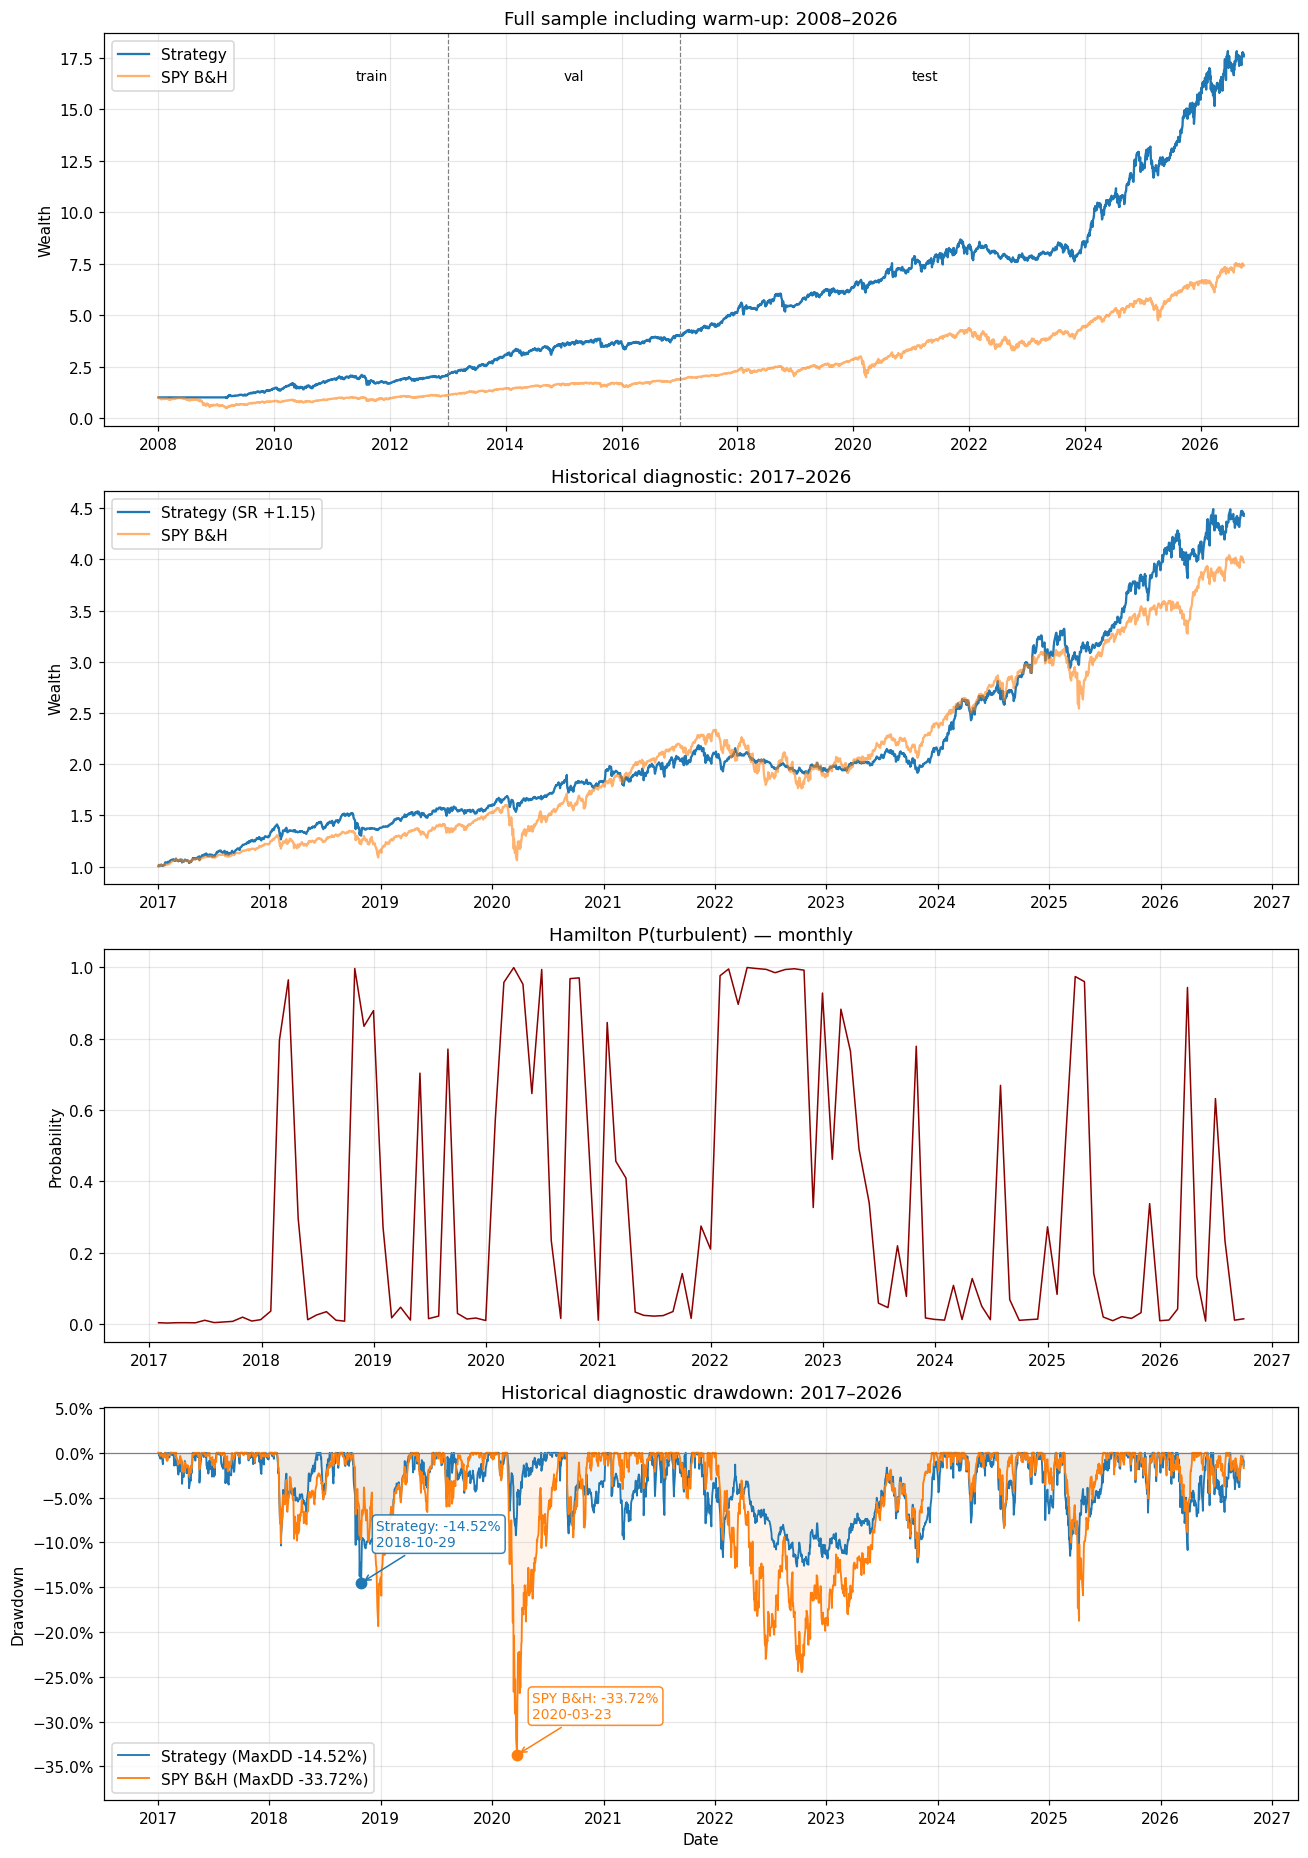

In [26]:
from matplotlib.ticker import PercentFormatter

m_t = masks_all["test"]; m_e = masks_e["test"]
fig, axes = plt.subplots(4, 1, figsize=(12, 17))

# --- 图1：全样本 train/val/test ---
ax = axes[0]
eq_full = (1 + net_full).cumprod()
eq_spy_full = (1 + net_b1).cumprod()

ax.plot(eq_full.index, eq_full.values, label="Strategy")
ax.plot(eq_spy_full.index, eq_spy_full.values, label="SPY B&H", alpha=.6)

for d in ["2013-01-01", "2017-01-01"]:
    ax.axvline(pd.Timestamp(d), color="gray", ls="--", lw=.8)

ax.text(pd.Timestamp("2011-06-01"), eq_full.max() * .92, "train", fontsize=9)
ax.text(pd.Timestamp("2015-01-01"), eq_full.max() * .92, "val", fontsize=9)
ax.text(pd.Timestamp("2021-01-01"), eq_full.max() * .92, "test", fontsize=9)
ax.set_title("Full sample including warm-up: 2008–2026")
ax.set_ylabel("Wealth")
ax.legend(); ax.grid(alpha=.3)

# --- 图2：历史诊断段净值 ---
ax = axes[1]
ax.plot(
    net_full[m_t].index, (1 + net_full[m_t]).cumprod(),
    label=f"Strategy (SR {metrics(net_full[m_t])['sharpe']:+.2f})"
)
ax.plot(net_b1[m_e].index, (1 + net_b1[m_e]).cumprod(), label="SPY B&H", alpha=.6)
ax.set_title("Historical diagnostic: 2017–2026")
ax.set_ylabel("Wealth")
ax.legend(); ax.grid(alpha=.3)

# --- 图3：Hamilton P(动荡) ---
ax = axes[2]
ps = p_stress.loc["2017-01-01":"2026-09-30"].dropna()

ax.plot(ps.index, ps.values, color="darkred", lw=1)
ax.set_title("Hamilton P(turbulent) — monthly")
ax.set_ylabel("Probability")
ax.set_ylim(-.05, 1.05); ax.grid(alpha=.3)

# --- 图4：历史诊断段回撤与最大回撤 ---
ax = axes[3]
diagnostic_returns = pd.concat(
    [net_full[m_t].rename("Strategy"), net_b1[m_e].rename("SPY B&H")], axis=1
)

if len(diagnostic_returns) < 2 or not np.isfinite(diagnostic_returns.to_numpy()).all():
    raise ValueError("策略与 SPY 的诊断段日期不一致、存在缺失值或数据不足。")
if (diagnostic_returns <= -1).any().any():
    raise ValueError("存在小于等于 -100% 的日收益，请检查数据。")

# 包含区间期初净值1，与 metrics() 的最大回撤口径一致
diagnostic_wealth = (1 + diagnostic_returns).cumprod()
running_peak = diagnostic_wealth.cummax().clip(lower=1.0)
drawdowns = diagnostic_wealth / running_peak - 1

colors = {"Strategy": "tab:blue", "SPY B&H": "tab:orange"}

for name, color in colors.items():
    dd = drawdowns[name]
    trough_date, max_dd = dd.idxmin(), float(dd.min())

    ax.plot(dd.index, dd, color=color, lw=1.2, label=f"{name} (MaxDD {max_dd:.2%})")
    ax.fill_between(dd.index, dd.to_numpy(), 0, color=color, alpha=.08)
    ax.scatter(trough_date, max_dd, color=color, s=45, zorder=5)
    ax.annotate(
        f"{name}: {max_dd:.2%}\n{trough_date:%Y-%m-%d}",
        xy=(trough_date, max_dd), xytext=(10, 24),
        textcoords="offset points", fontsize=9, color=color,
        arrowprops=dict(arrowstyle="->", color=color),
        bbox=dict(boxstyle="round,pad=.3", fc="white", ec=color, alpha=.9)
    )

ax.axhline(0, color="gray", lw=.8)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Historical diagnostic drawdown: 2017–2026")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.legend(loc="lower left"); ax.grid(alpha=.3)
ax.margins(y=.15)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "Strategy_equity.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Interpretation and limitations

The source output reports historical diagnostic CAGR **16.54%**, zero-risk-free Sharpe **1.147**, and maximum drawdown **−14.52%**; SPY reports **15.25%**, **0.874**, and **−33.72%**. These values describe the saved run and are not a new full rerun performed during publication.

The research question is the price of protection. User-reported comparisons show pure momentum with higher CAGR but substantially deeper drawdown. Simple monthly volatility scaling and risk-adjusted ranking did not consistently dominate the baseline; see `docs/EXPERIMENTS.md` for complete rounded tables and evidence status.

The main limitations are current-constituent survivorship bias, repeated observation of the historical test interval, unverified price adjustment provenance, fixed cost assumptions, zero cash yield, and a small number of independent tail events. Weekly estimation and monthly execution also limit response speed. High volatility is not synonymous with negative returns.

Next steps should prioritize point-in-time membership and delistings, a frozen prospective evaluation protocol, exposure-matched simple baselines, cost/capacity stress and selection-aware uncertainty—not a larger search over the already observed test period.

The repository preserves the supplied numerical core, adds portable I/O and lightweight boundary tests, and documents both positive and negative findings. See `docs/METHODOLOGY.md`, `docs/LIMITATIONS.md`, and `results/published/README.md`.
